In [10]:
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from scipy.stats import chi2
import os



# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format



#### FACE DATA AND LOGIT REGRESSION

In [11]:
s = pandas.read_csv(r'data\sample_v10.csv')
s

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,10.0071000000,-3.8675000000,6.6899000000,33.1367000000,24.3674000000,-1.7803000000,-1.2021000000,-49.9108000000,-35.0150000000,-69.6709000000,Bicycle
1,4.0799000000,5.3650000000,22.6921000000,5.8840000000,-7.3794000000,9.4086000000,-47.1878000000,-26.5750000000,90.0186000000,51.9291000000,Walk
2,4.4219000000,-5.1384000000,19.9140000000,30.2850000000,18.3257000000,-7.5855000000,-4.9785000000,-43.7822000000,27.4785000000,-24.0543000000,Bicycle
3,2.4046000000,1.0938000000,-22.8637000000,47.5924000000,4.2035000000,29.6571000000,22.1897000000,-9.1959000000,75.0079000000,4.3526000000,Taxi
4,-3.1989000000,10.1843000000,-9.7620000000,-7.9439000000,2.7512000000,5.4564000000,-20.1493000000,-3.7285000000,9.7938000000,16.1566000000,Bus
...,...,...,...,...,...,...,...,...,...,...,...
27508,6.1270000000,9.4777000000,4.3077000000,-7.3817000000,24.4101000000,-0.3243000000,2.1309000000,38.1617000000,-5.7506000000,13.2968000000,Taxi
27509,-5.6725000000,4.9998000000,33.6681000000,13.6434000000,-30.4055000000,18.9886000000,-11.7792000000,-86.2325000000,66.2832000000,-82.3173000000,Bus
27510,-0.0443000000,-1.3835000000,-6.4840000000,5.6434000000,-46.5130000000,-57.6832000000,-11.4380000000,-24.5850000000,48.7796000000,-31.5079000000,Bus
27511,6.0182000000,-11.1837000000,5.7115000000,-2.4476000000,62.0375000000,31.3134000000,2.3513000000,-59.9128000000,80.2141000000,55.8140000000,Bicycle


In [12]:
from sklearn.model_selection import train_test_split

# Perform stratified train-test split
# 70% training, 30% testing, stratified by Label, random_state=20231225
X = s.drop('y', axis=1)
y = s['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=20231225
)

# Create full training and testing dataframes
train_data = X_train.copy()
train_data['y'] = y_train

test_data = X_test.copy()
test_data['y'] = y_test

# Print partition sizes
print("="*70)
print("PARTITION SIZES")
print("="*70)
print(f"Total observations: {len(s):,}")
print(f"Training partition: {len(train_data):,} observations ({len(train_data)/len(s)*100:.1f}%)")
print(f"Testing partition: {len(test_data):,} observations ({len(test_data)/len(s)*100:.1f}%)")

# Calculate relative frequencies of target categories
print("\n" + "="*70)
print("RELATIVE FREQUENCIES OF TARGET CATEGORIES")
print("="*70)

print("\nOriginal Data:")
original_freq = y.value_counts(normalize=True).sort_index()
for label, freq in original_freq.items():
    print(f"  Label {label}: {freq:.6f} ({freq*100:.2f}%)")

print("\nTraining Partition:")
train_freq = y_train.value_counts(normalize=True).sort_index()
for label, freq in train_freq.items():
    print(f"  Label {label}: {freq:.6f} ({freq*100:.2f}%)")

print("\nTesting Partition:")
test_freq = y_test.value_counts(normalize=True).sort_index()
for label, freq in test_freq.items():
    print(f"  Label {label}: {freq:.6f} ({freq*100:.2f}%)")

print("\n" + "="*70)

PARTITION SIZES
Total observations: 27,513
Training partition: 19,259 observations (70.0%)
Testing partition: 8,254 observations (30.0%)

RELATIVE FREQUENCIES OF TARGET CATEGORIES

Original Data:
  Label Bicycle: 0.266856 (26.69%)
  Label Bus: 0.135282 (13.53%)
  Label Others: 0.134518 (13.45%)
  Label Taxi: 0.230945 (23.09%)
  Label Walk: 0.232399 (23.24%)

Training Partition:
  Label Bicycle: 0.266836 (26.68%)
  Label Bus: 0.135261 (13.53%)
  Label Others: 0.134535 (13.45%)
  Label Taxi: 0.230957 (23.10%)
  Label Walk: 0.232411 (23.24%)

Testing Partition:
  Label Bicycle: 0.266901 (26.69%)
  Label Bus: 0.135328 (13.53%)
  Label Others: 0.134480 (13.45%)
  Label Taxi: 0.230918 (23.09%)
  Label Walk: 0.232372 (23.24%)



In [13]:
# Train a classification tree using all ten predictors. The impurity metric is Entropy. We will try the depth of the tree from 1 to 20. After training the tree, we will apply the model to the Testing partition and calculate the accuracy. Please plot in the same chart the accuracy values as two separate series (one for Training and another for Testing) versus the depth of the tree
# We provide you with the sample_v10.csv that contains 27,513 observations on a categorical label variable y and ten continuous features are x1, x2, x3, x4, x5, x6, x7, x8, x9, and x10.The label variable has five categories, namely, Bicycle, Bus, Others, Taxi, and Walk. We want to train a classification tree model to predict the label variable. For classification, you will classify an observation into a target category whose predicted probability is the highest. In case of ties, choose the lexically lower target category. To help us determine the depth of the tree, we will use a Testing partition.



Depth  1: Train Accuracy = 0.301469, Test Accuracy = 0.300460
Depth  2: Train Accuracy = 0.335324, Test Accuracy = 0.329780
Depth  3: Train Accuracy = 0.355159, Test Accuracy = 0.347468
Depth  4: Train Accuracy = 0.367984, Test Accuracy = 0.356918
Depth  5: Train Accuracy = 0.386417, Test Accuracy = 0.370729
Depth  6: Train Accuracy = 0.398515, Test Accuracy = 0.370487
Depth  7: Train Accuracy = 0.415909, Test Accuracy = 0.367095
Depth  8: Train Accuracy = 0.437614, Test Accuracy = 0.364308
Depth  9: Train Accuracy = 0.470689, Test Accuracy = 0.368185
Depth 10: Train Accuracy = 0.519186, Test Accuracy = 0.351829
Depth 11: Train Accuracy = 0.575212, Test Accuracy = 0.351102
Depth 12: Train Accuracy = 0.643336, Test Accuracy = 0.335716
Depth 13: Train Accuracy = 0.712913, Test Accuracy = 0.329174
Depth 14: Train Accuracy = 0.782387, Test Accuracy = 0.322631
Depth 15: Train Accuracy = 0.838932, Test Accuracy = 0.314756
Depth 16: Train Accuracy = 0.887273, Test Accuracy = 0.309305
Depth 17

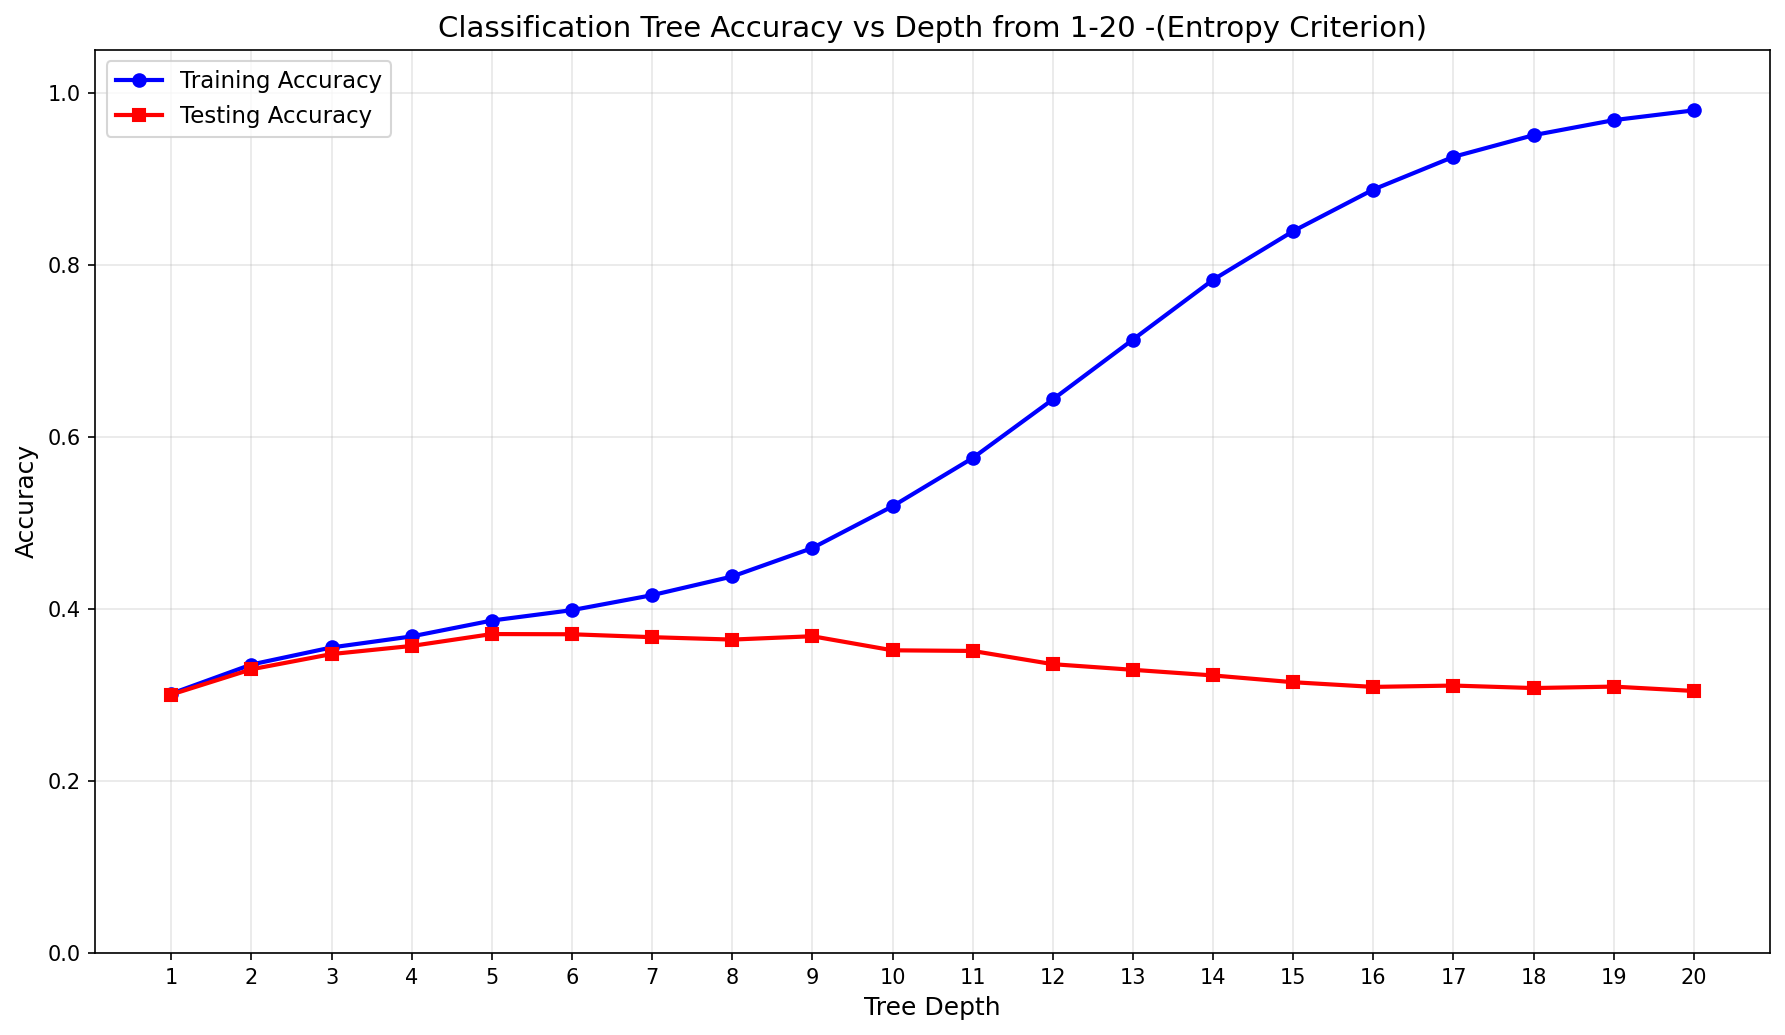


Best Testing Accuracy: 0.370729 at depth 5


In [16]:
from sklearn import tree

# Function to predict with tie-breaking (lexically lower category)
def predict_with_tie_breaking(model, X, classes):
    """
    Predict class labels with tie-breaking rule:
    In case of ties, choose the lexically lower target category.
    """
    # Get predicted probabilities for all classes
    probs = model.predict_proba(X)
    
    # Find the maximum probability for each observation
    max_probs = probs.max(axis=1)
    
    # For each observation, find which classes have the max probability
    predictions = []
    for i in range(len(probs)):
        # Find all classes with maximum probability
        max_indices = numpy.where(probs[i] == max_probs[i])[0]
        # Get the class names for these indices
        tied_classes = [classes[idx] for idx in max_indices]
        # Choose the lexically lowest (sorted alphabetically)
        chosen_class = sorted(tied_classes)[0]
        predictions.append(chosen_class)
    
    return numpy.array(predictions)

# Lists to store accuracy results
depths = list(range(1, 21))
train_accuracies = []
test_accuracies = []

# Train trees with different depths
for depth in depths:
    # Create and train the classification tree
    classTree = tree.DecisionTreeClassifier(
        criterion='entropy', 
        max_depth=depth, 
        random_state=20231225
    )
    
    # Fit the model
    classTree.fit(X_train, y_train)
    
    # Get class labels (sorted to ensure consistent ordering)
    classes = classTree.classes_
    
    # Predict with tie-breaking rule for training set
    y_train_pred = predict_with_tie_breaking(classTree, X_train, classes)
    train_accuracy = numpy.mean(y_train_pred == y_train)
    train_accuracies.append(train_accuracy)
    
    # Predict with tie-breaking rule for testing set
    y_test_pred = predict_with_tie_breaking(classTree, X_test, classes)
    test_accuracy = numpy.mean(y_test_pred == y_test)
    test_accuracies.append(test_accuracy)
    
    print(f"Depth {depth:2d}: Train Accuracy = {train_accuracy:.6f}, Test Accuracy = {test_accuracy:.6f}")

# Create the plot
plt.figure(figsize=(12, 7), dpi=150)
plt.plot(depths, train_accuracies, marker='o', linestyle='-', linewidth=2, 
         markersize=6, label='Training Accuracy', color='blue')
plt.plot(depths, test_accuracies, marker='s', linestyle='-', linewidth=2, 
         markersize=6, label='Testing Accuracy', color='red')

plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Classification Tree Accuracy vs Depth from 1-20 -(Entropy Criterion)', fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

# Find the best depth based on testing accuracy
best_depth = depths[test_accuracies.index(max(test_accuracies))]
best_test_acc = max(test_accuracies)
print(f"\n{'='*70}")
print(f"Best Testing Accuracy: {best_test_acc:.6f} at depth {best_depth}")
print(f"{'='*70}")

Retraining decision tree with depth = 5
Class labels: ['Bicycle', 'Bus', 'Others', 'Taxi', 'Walk']


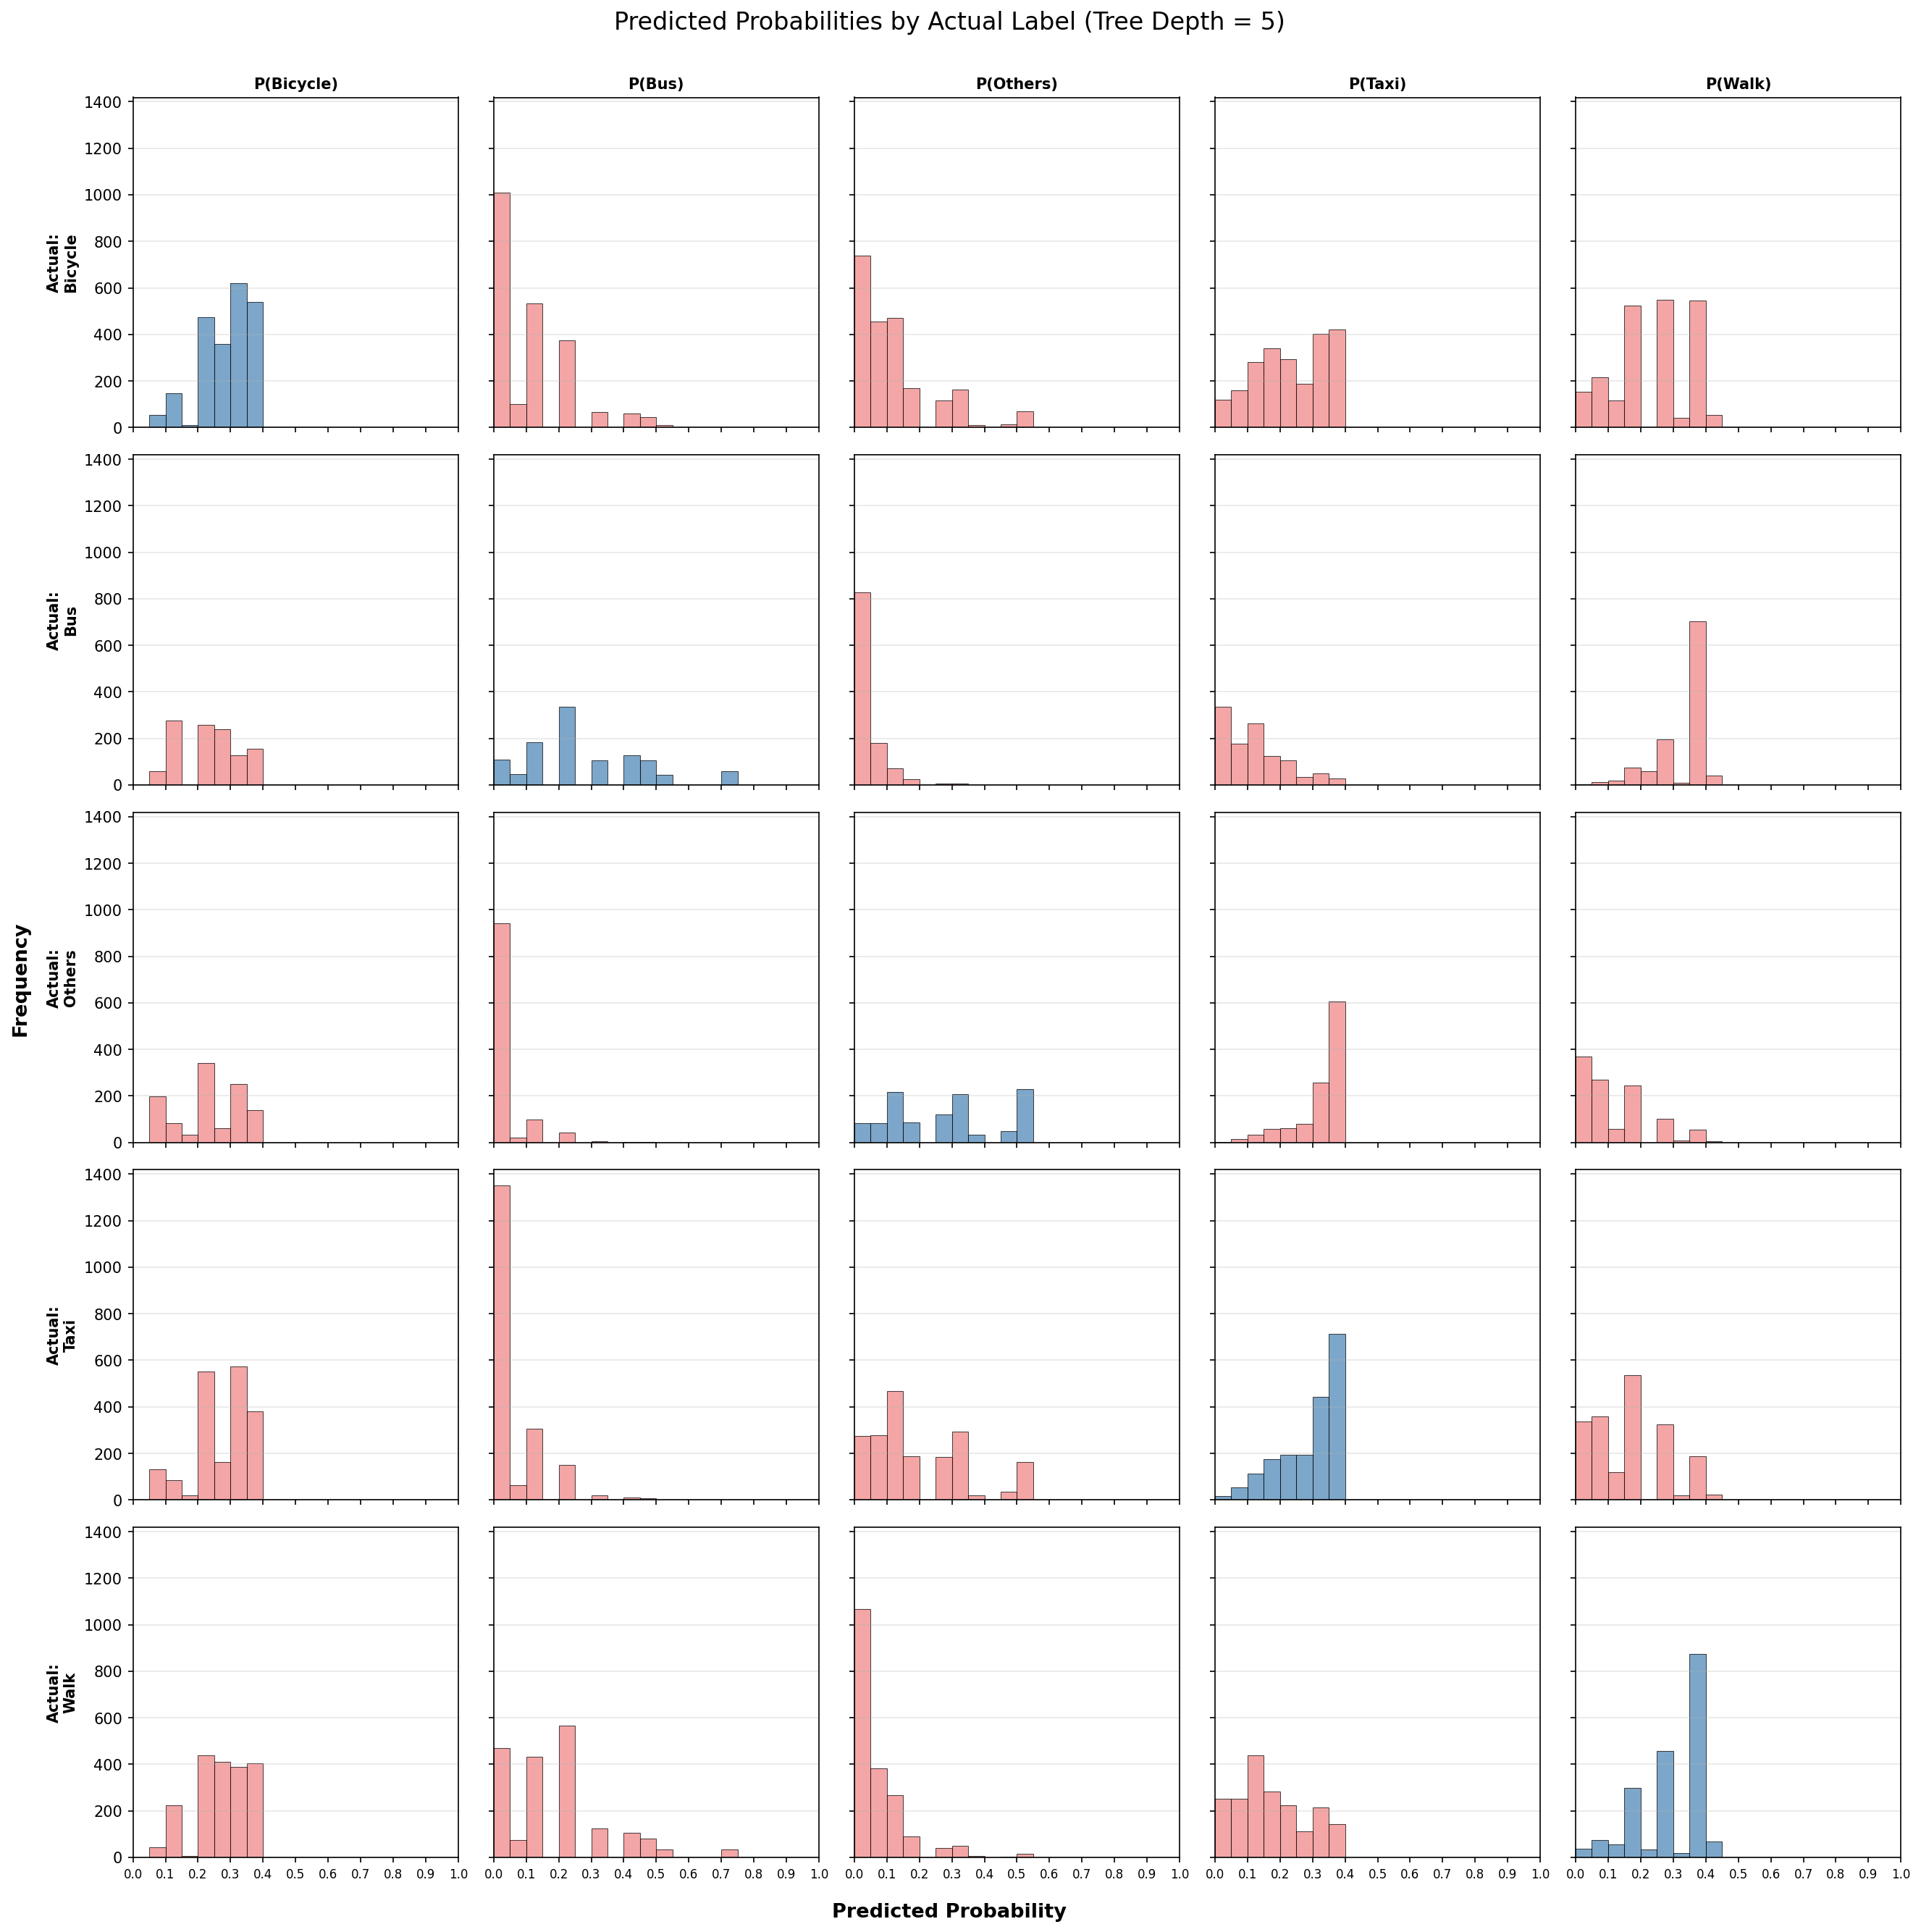


Test Accuracy: 0.370729


In [15]:
# Retrain the decision tree using your choice for the tree depth on the Training partition. Next, calculate the predicted probabilities for the Testing partition. Finally, generate a 5 x 5 matrix of histograms for the predicted probabilities. For the first row, you will select the observations where the Label value is Bicycle. Next, generate a histogram for each predicted probability and put the five histograms in their respective cells on the first row. The second row is for the observations where the Label value is Bus. The other rows will follow suit. The common bin width in the histograms is 0.05. The common horizontal tick marks are from 0 to 1 with an increment of 0.1. The histograms share the same vertical tick marks.

# Retrain the decision tree with the best depth
print(f"Retraining decision tree with depth = {best_depth}")
final_tree = tree.DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=best_depth, 
    random_state=20231225
)
final_tree.fit(X_train, y_train)

# Calculate predicted probabilities for the Testing partition
test_probs = final_tree.predict_proba(X_test)

# Get class labels (sorted alphabetically)
class_labels = sorted(final_tree.classes_)
print(f"Class labels: {class_labels}")

# Create DataFrame for easier filtering
prob_df = pandas.DataFrame(test_probs, columns=[f'Prob_{label}' for label in final_tree.classes_])
prob_df['Actual'] = y_test.values

# Generate 5x5 matrix of histograms
fig, axes = plt.subplots(5, 5, figsize=(18, 18), sharex=True, sharey=True, dpi=150)
fig.suptitle(f'Predicted Probabilities by Actual Label (Tree Depth = {best_depth})', 
             fontsize=16, y=0.995)

# Define bins for histograms (bin width = 0.05)
bins = numpy.arange(0, 1.05, 0.05)

# Generate histograms
for i, actual_label in enumerate(class_labels):
    # Filter data for this actual label
    mask = prob_df['Actual'] == actual_label
    subset = prob_df[mask]
    
    for j, pred_label in enumerate(class_labels):
        ax = axes[i, j]
        
        # Get the predicted probabilities for this class
        prob_col = f'Prob_{pred_label}'
        probs = subset[prob_col]
        
        # Create histogram
        color = 'steelblue' if i == j else 'lightcoral'
        ax.hist(probs, bins=bins, color=color, edgecolor='black', alpha=0.7, linewidth=0.5)
        
        # Set title only for top row
        if i == 0:
            ax.set_title(f'P({pred_label})', fontsize=10, fontweight='bold')
        
        # Set ylabel only for first column
        if j == 0:
            ax.set_ylabel(f'Actual:\n{actual_label}', fontsize=10, fontweight='bold')
        
        # Set x-axis properties
        ax.set_xticks(numpy.arange(0, 1.1, 0.1))
        if i == 4:  # Bottom row
            ax.tick_params(axis='x', labelsize=8)
        
        # Grid
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(0, 1)

# Add common axis labels
fig.text(0.5, 0.02, 'Predicted Probability', ha='center', fontsize=13, fontweight='bold')
fig.text(0.02, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0.03, 0.03, 1, 0.99])
plt.show()

# Print summary
print(f"\nTest Accuracy: {final_tree.score(X_test, y_test):.6f}")